In [ ]:
# install dependencies in the right order
# huggingface_hub must come first since transformers depends on it

!pip install -q "huggingface_hub>=0.32.0" --upgrade
!pip install -q "transformers>=4.51.0" --upgrade
!pip install -q "peft>=0.15.0" "trl>=1.3.0" "bitsandbytes>=0.45.0" "accelerate>=1.0.0" "qwen-vl-utils>=0.0.8" --upgrade



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 661.5/661.5 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 80.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 91.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 680.7/680.7 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 721.6/721.6 kB 37.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 54.4 MB/s eta 0:00:00


In [2]:
import os
import json
import random
from PIL import Image

import torch
from torch.utils.data import Dataset

from transformers import (
    Qwen2VLForConditionalGeneration,
    AutoProcessor,
    BitsAndBytesConfig,
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from trl import SFTTrainer, SFTConfig
from qwen_vl_utils import process_vision_info

import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device} | gpu count: {torch.cuda.device_count()}")
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f"{props.name} | {props.total_memory / 1e9:.1f} gb")

device: cuda | gpu count: 2
Tesla T4 | 15.6 gb


In [3]:
config = {
    "model_name": "Qwen/Qwen2-VL-2B-Instruct",
    "data_root": "/kaggle/input/datasets/zphilip/nougat-training-dataset-example/0508",
    "image_size": 512,
    "max_seq_length": 1024,
    "batch_size": 1,
    "grad_accum": 8,
    "epochs": 3,
    "lr": 2e-4,
    "lora_rank": 16,
    "lora_alpha": 32,
    "lora_dropout": 0.05,
    "train_split": 0.8,
    "max_samples": 800,
    "system_prompt": "You are a document understanding assistant that converts document images into structured Markdown.",
    "user_prompt": "Convert this document image into Markdown. Preserve all headings, paragraphs, equations, and formatting.",
}

from tqdm import tqdm

pairs = []
corrupted = []

for dirpath, _, filenames in os.walk(config["data_root"]):
    for f in filenames:
        if f.lower().endswith(".png"):
            img_path = os.path.join(dirpath, f)
            base = os.path.splitext(f)[0]
            md_path = os.path.join(dirpath, base + ".mmd")

            if not os.path.exists(md_path):
                continue

            # validate the image is actually readable
            # this catches corrupted, truncated, or zero-byte files
            try:
                img = Image.open(img_path)
                img.verify()  # checks file integrity without fully loading
                # verify() closes the file, need to reopen for size check
                img = Image.open(img_path)
                w, h = img.size
                if w < 10 or h < 10:  # skip tiny garbage images
                    corrupted.append(img_path)
                    continue
                img.close()
            except Exception:
                corrupted.append(img_path)
                continue

            with open(md_path, "r", encoding="utf-8") as fh:
                text = fh.read().strip()
            if len(text) > 20:
                pairs.append({"image_path": img_path, "markdown": text})

print(f"valid pairs: {len(pairs)}")
print(f"corrupted/skipped images: {len(corrupted)}")
if corrupted:
    for c in corrupted[:5]:
        print(f"  skipped: {os.path.basename(c)}")
    if len(corrupted) > 5:
        print(f"  ... and {len(corrupted) - 5} more")

lens = [len(p["markdown"]) for p in pairs]
print(f"markdown chars - min: {min(lens)} avg: {sum(lens)//len(lens)} max: {max(lens)}")

random.seed(42)
random.shuffle(pairs)
if config["max_samples"]:
    pairs = pairs[:config["max_samples"]]
print(f"using {len(pairs)} pairs for training")

valid pairs: 14186
corrupted/skipped images: 29
  skipped: 45.png
  skipped: 10.png
  skipped: 11.png
  skipped: 14.png
  skipped: 14.png
  ... and 24 more
markdown chars - min: 21 avg: 3172 max: 59339
using 800 pairs for training


In [4]:
# convert pairs to chatml format expected by qwen2-vl

def to_chatml(pair):
    return {
        "messages": [
            {"role": "system", "content": [{"type": "text", "text": config["system_prompt"]}]},
            {"role": "user", "content": [
                {"type": "image", "image": pair["image_path"]},
                {"type": "text", "text": config["user_prompt"]},
            ]},
            {"role": "assistant", "content": [{"type": "text", "text": pair["markdown"]}]},
        ]
    }

# truncate long markdown so it fits in max_seq_length (~4 chars per token)
max_chars = config["max_seq_length"] * 4
chatml = []
for p in pairs:
    if len(p["markdown"]) > max_chars:
        p = {**p, "markdown": p["markdown"][:max_chars].rsplit("\n", 1)[0]}
    chatml.append(to_chatml(p))

# 80/20 split
split = int(len(chatml) * config["train_split"])
train_data = chatml[:split]
val_data = chatml[split:]
print(f"train: {len(train_data)} | val: {len(val_data)}")

class VLMDataset(Dataset):
    def __init__(self, data):
        self.data = data
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        return self.data[idx]

train_dataset = VLMDataset(train_data)
val_dataset = VLMDataset(val_data)

train: 640 | val: 160


In [ ]:
processor = AutoProcessor.from_pretrained(
    config["model_name"],
    min_pixels=256 * 256,
    max_pixels=config["image_size"] * config["image_size"],
)
if processor.tokenizer.pad_token is None:
    processor.tokenizer.pad_token = processor.tokenizer.eos_token

def collate_fn(batch):
    texts, images = [], []
    skipped = 0

    for sample in batch:
        msgs = sample["messages"]
        try:
            # try processing this sample's image
            imgs, _ = process_vision_info(msgs)
            # if we got here, image loaded successfully
            text = processor.apply_chat_template(msgs, tokenize=False, add_generation_prompt=False)
            texts.append(text)
            images.extend(imgs)
        except Exception:
            # corrupted image slipped through validation — skip this sample
            skipped += 1
            continue

    if not texts:
       
        return None

    inputs = processor(
        text=texts,
        images=images if images else None,
        padding=True,
        truncation=True,
        max_length=config["max_seq_length"],
        return_tensors="pt",
    )

    labels = inputs["input_ids"].clone()
    labels[labels == processor.tokenizer.pad_token_id] = -100
    inputs["labels"] = labels
    return inputs

print("processor and collator ready")

preprocessor_config.json:   0%|          | 0.00/347 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

processor and collator ready


In [6]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

model = Qwen2VLForConditionalGeneration.from_pretrained(
    config["model_name"],
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.float16,
    trust_remote_code=True,
)

model = prepare_model_for_kbit_training(model, use_gradient_checkpointing=True)

lora_config = LoraConfig(
    r=config["lora_rank"],
    lora_alpha=config["lora_alpha"],
    lora_dropout=config["lora_dropout"],
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    bias="none",
    task_type="CAUSAL_LM",
)
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/272 [00:00<?, ?B/s]

trainable params: 18,464,768 || all params: 2,227,450,368 || trainable%: 0.8290


In [ ]:
output_dir = "/kaggle/working/qwen2vl-nougat"

steps_per_epoch = len(train_dataset) // (config["batch_size"] * config["grad_accum"])
warmup = max(1, int(steps_per_epoch * config["epochs"] * 0.1))

training_args = SFTConfig(
    output_dir=output_dir,
    num_train_epochs=config["epochs"],
    per_device_train_batch_size=config["batch_size"],
    per_device_eval_batch_size=config["batch_size"],
    gradient_accumulation_steps=config["grad_accum"],
    learning_rate=config["lr"],
    weight_decay=0.01,
    warmup_steps=warmup,
    lr_scheduler_type="cosine",
    gradient_checkpointing=True,
    max_grad_norm=1.0,
    logging_steps=10,
    eval_strategy="epoch",
    save_strategy="steps",
    save_steps=20,           
    save_total_limit=3,      
    load_best_model_at_end=False,  
    dataset_kwargs={"skip_prepare_dataset": True},
    remove_unused_columns=False,
    report_to="none",
    dataloader_pin_memory=True,
)

trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=collate_fn,
    processing_class=processor.tokenizer,
)

import glob
checkpoints = sorted(glob.glob(f"{output_dir}/checkpoint-*"))
resume_from = checkpoints[-1] if checkpoints else None
if resume_from:
    print(f"resuming from: {resume_from}")
else:
    print("starting fresh")

result = trainer.train(resume_from_checkpoint=resume_from)
print(f"training time: {result.metrics['train_runtime']/60:.1f} min")
print(f"final train loss: {result.metrics['train_loss']:.4f}")

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 151645, 'bos_token_id': None, 'pad_token_id': 151643}.


starting fresh


Epoch,Training Loss,Validation Loss
1,2.655411,2.769806
2,2.698589,2.752700
3,2.716513,2.753110


training time: 280.9 min
final train loss: 2.9048


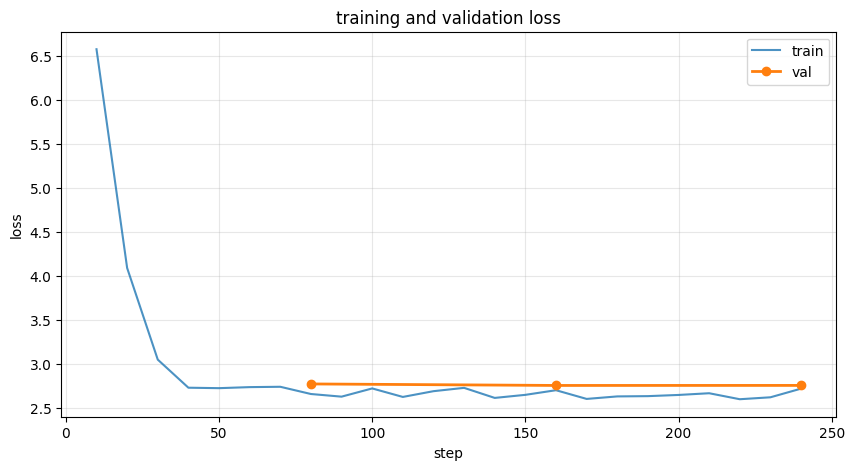

final train: 2.7165 | final val: 2.7531


In [ ]:
# save lora adapters 50 MB Maybe - much smaller than full model
adapter_path = "/kaggle/working/qwen2vl-nougat-adapter"
model.save_pretrained(adapter_path)
processor.save_pretrained(adapter_path)

logs = trainer.state.log_history
train_loss = [(e["step"], e["loss"]) for e in logs if "loss" in e and "eval_loss" not in e]
val_loss = [(e["step"], e["eval_loss"]) for e in logs if "eval_loss" in e]

plt.figure(figsize=(10, 5))
if train_loss:
    s, l = zip(*train_loss)
    plt.plot(s, l, label="train", alpha=0.8)
if val_loss:
    s, l = zip(*val_loss)
    plt.plot(s, l, label="val", marker="o", linewidth=2)
plt.xlabel("step")
plt.ylabel("loss")
plt.title("training and validation loss")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("/kaggle/working/loss_curve.png", dpi=150, bbox_inches="tight")
plt.show()

if train_loss and val_loss:
    print(f"final train: {train_loss[-1][1]:.4f} | final val: {val_loss[-1][1]:.4f}")

In [9]:
def generate_md(image_path, mdl=None, proc=None, max_tokens=1024):
    mdl = mdl if mdl is not None else model
    proc = proc if proc is not None else processor
    msgs = [
        {"role": "system", "content": [{"type": "text", "text": config["system_prompt"]}]},
        {"role": "user", "content": [
            {"type": "image", "image": image_path},
            {"type": "text", "text": config["user_prompt"]},
        ]},
    ]
    text = proc.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    imgs, _ = process_vision_info(msgs)
    inputs = proc(text=[text], images=imgs, padding=True, return_tensors="pt")
    inputs = {k: v.to(mdl.device) if isinstance(v, torch.Tensor) else v for k, v in inputs.items()}

    with torch.no_grad():
        out = mdl.generate(**inputs, max_new_tokens=max_tokens, do_sample=False, repetition_penalty=1.1)
    out = out[:, inputs["input_ids"].shape[1]:]
    return proc.batch_decode(out, skip_special_tokens=True)[0].strip()

def get_sample_info(sample):
    img, gt = None, None
    for m in sample["messages"]:
        if m["role"] == "user":
            for c in m["content"]:
                if c["type"] == "image":
                    img = c["image"]
        elif m["role"] == "assistant":
            for c in m["content"]:
                if c["type"] == "text":
                    gt = c["text"]
    return img, gt

# generate on 3 train + 3 val samples
train_results, val_results = [], []

for i, idx in enumerate([0, len(train_data) // 2, len(train_data) - 1]):
    img, gt = get_sample_info(train_data[idx])
    pred = generate_md(img)
    train_results.append({"image_path": img, "ground_truth": gt, "generated": pred})
    print(f"train sample {i+1} done | gt: {len(gt)} chars | gen: {len(pred)} chars")

for i, idx in enumerate([0, len(val_data) // 2, len(val_data) - 1]):
    img, gt = get_sample_info(val_data[idx])
    pred = generate_md(img)
    val_results.append({"image_path": img, "ground_truth": gt, "generated": pred})
    print(f"val sample {i+1} done | gt: {len(gt)} chars | gen: {len(pred)} chars")

train sample 1 done | gt: 3085 chars | gen: 3066 chars
train sample 2 done | gt: 173 chars | gen: 175 chars
train sample 3 done | gt: 3687 chars | gen: 3610 chars
val sample 1 done | gt: 3154 chars | gen: 3147 chars
val sample 2 done | gt: 3162 chars | gen: 3140 chars
val sample 3 done | gt: 3358 chars | gen: 3039 chars


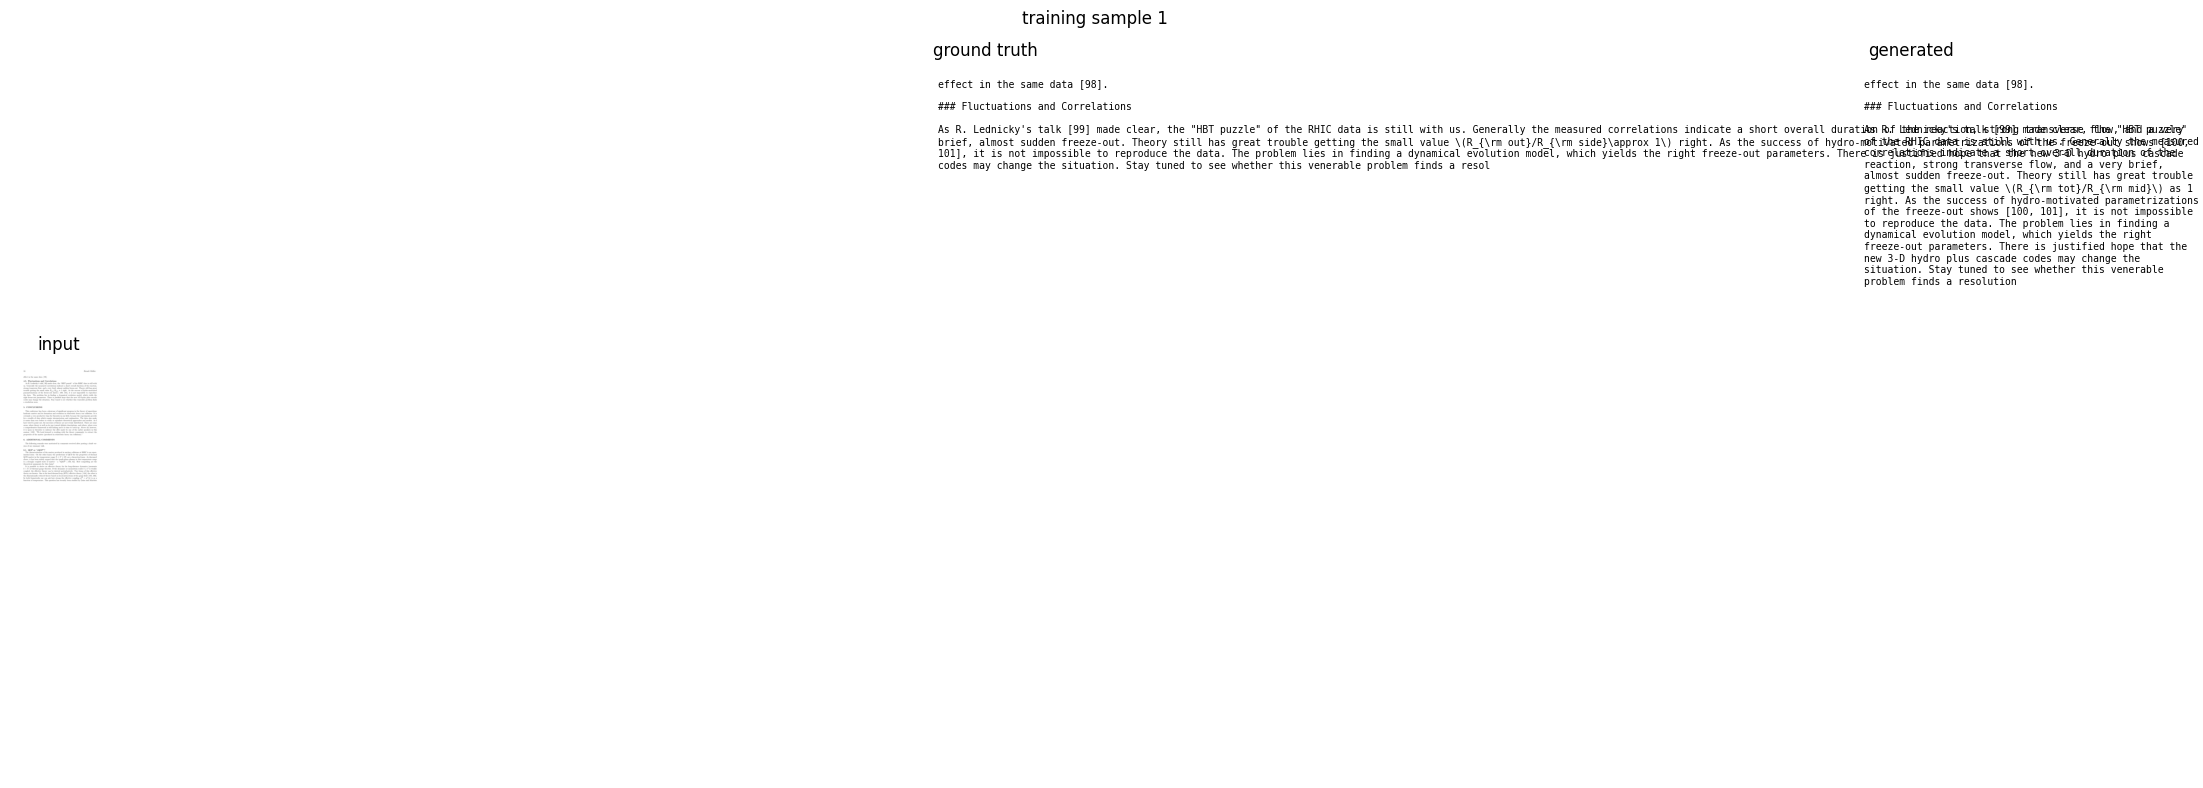

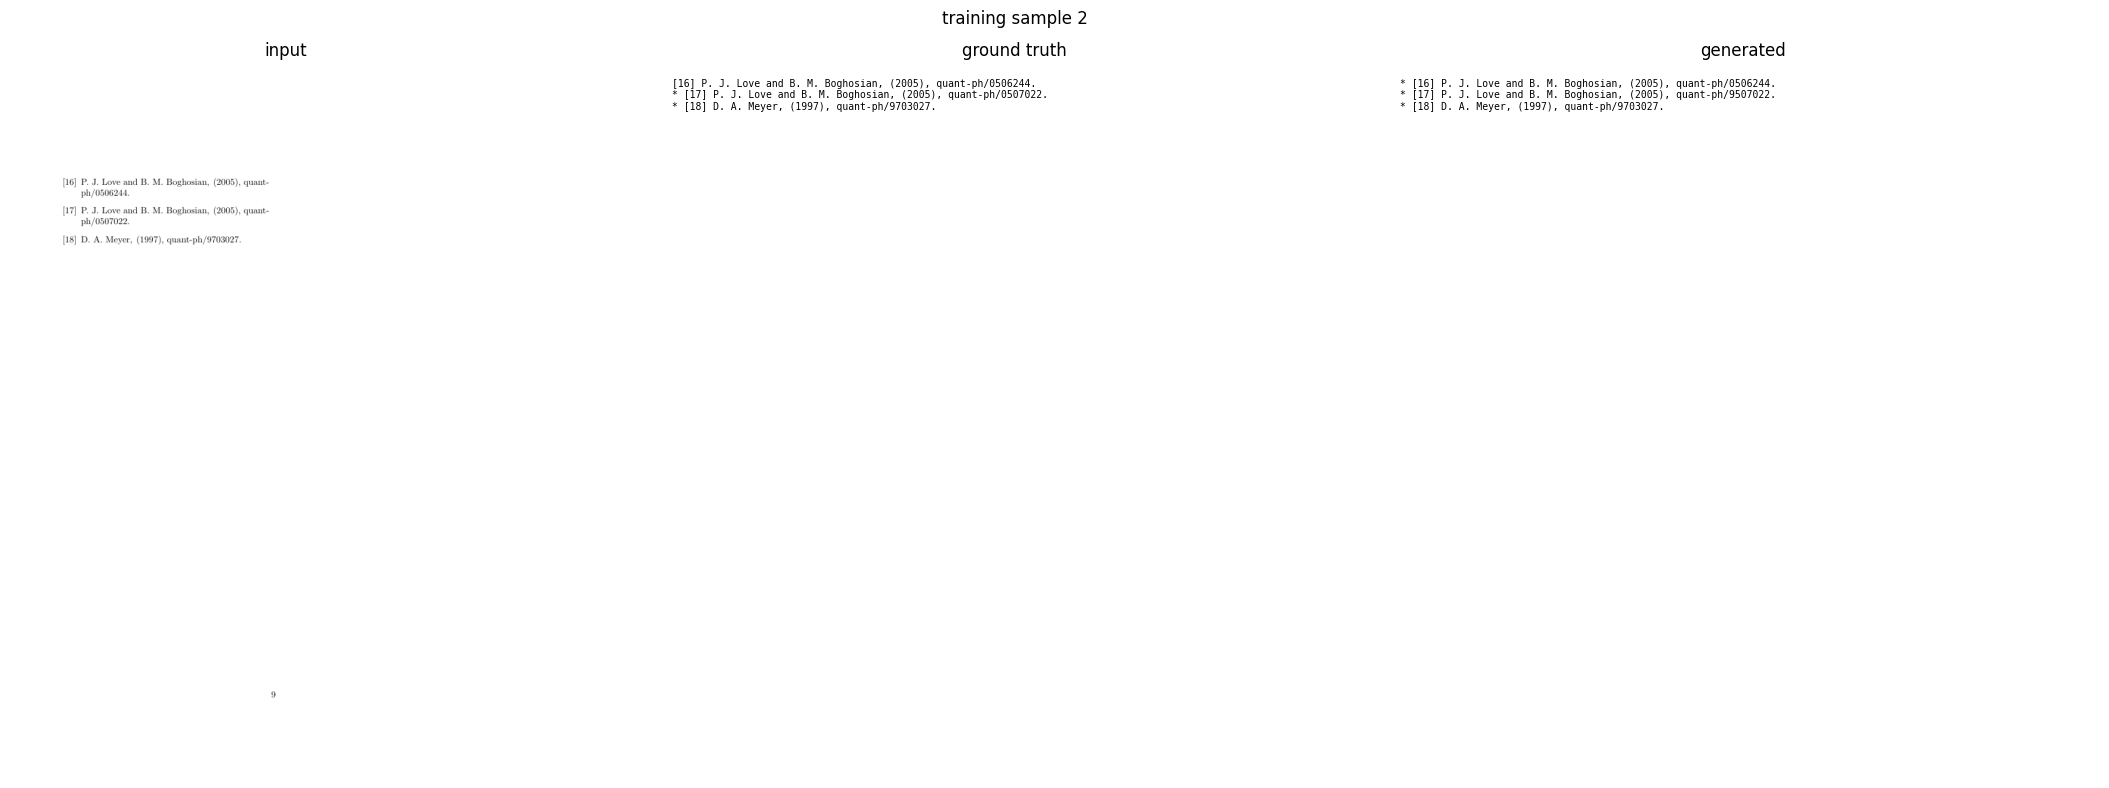

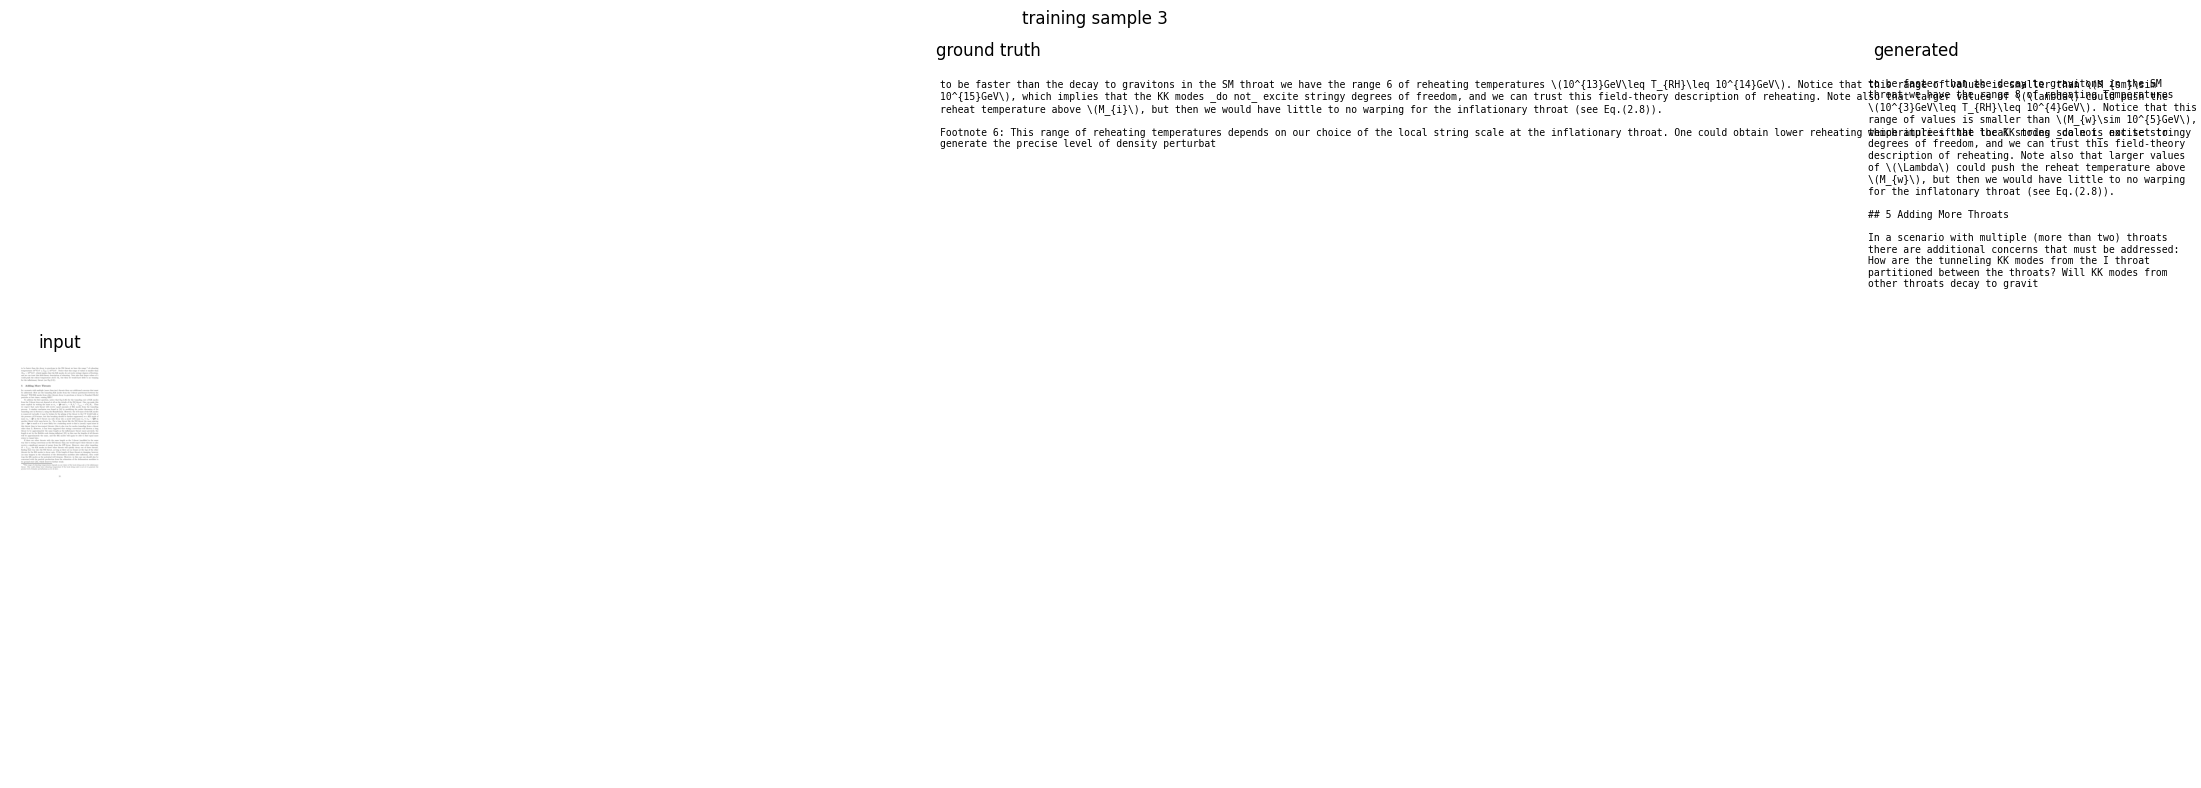

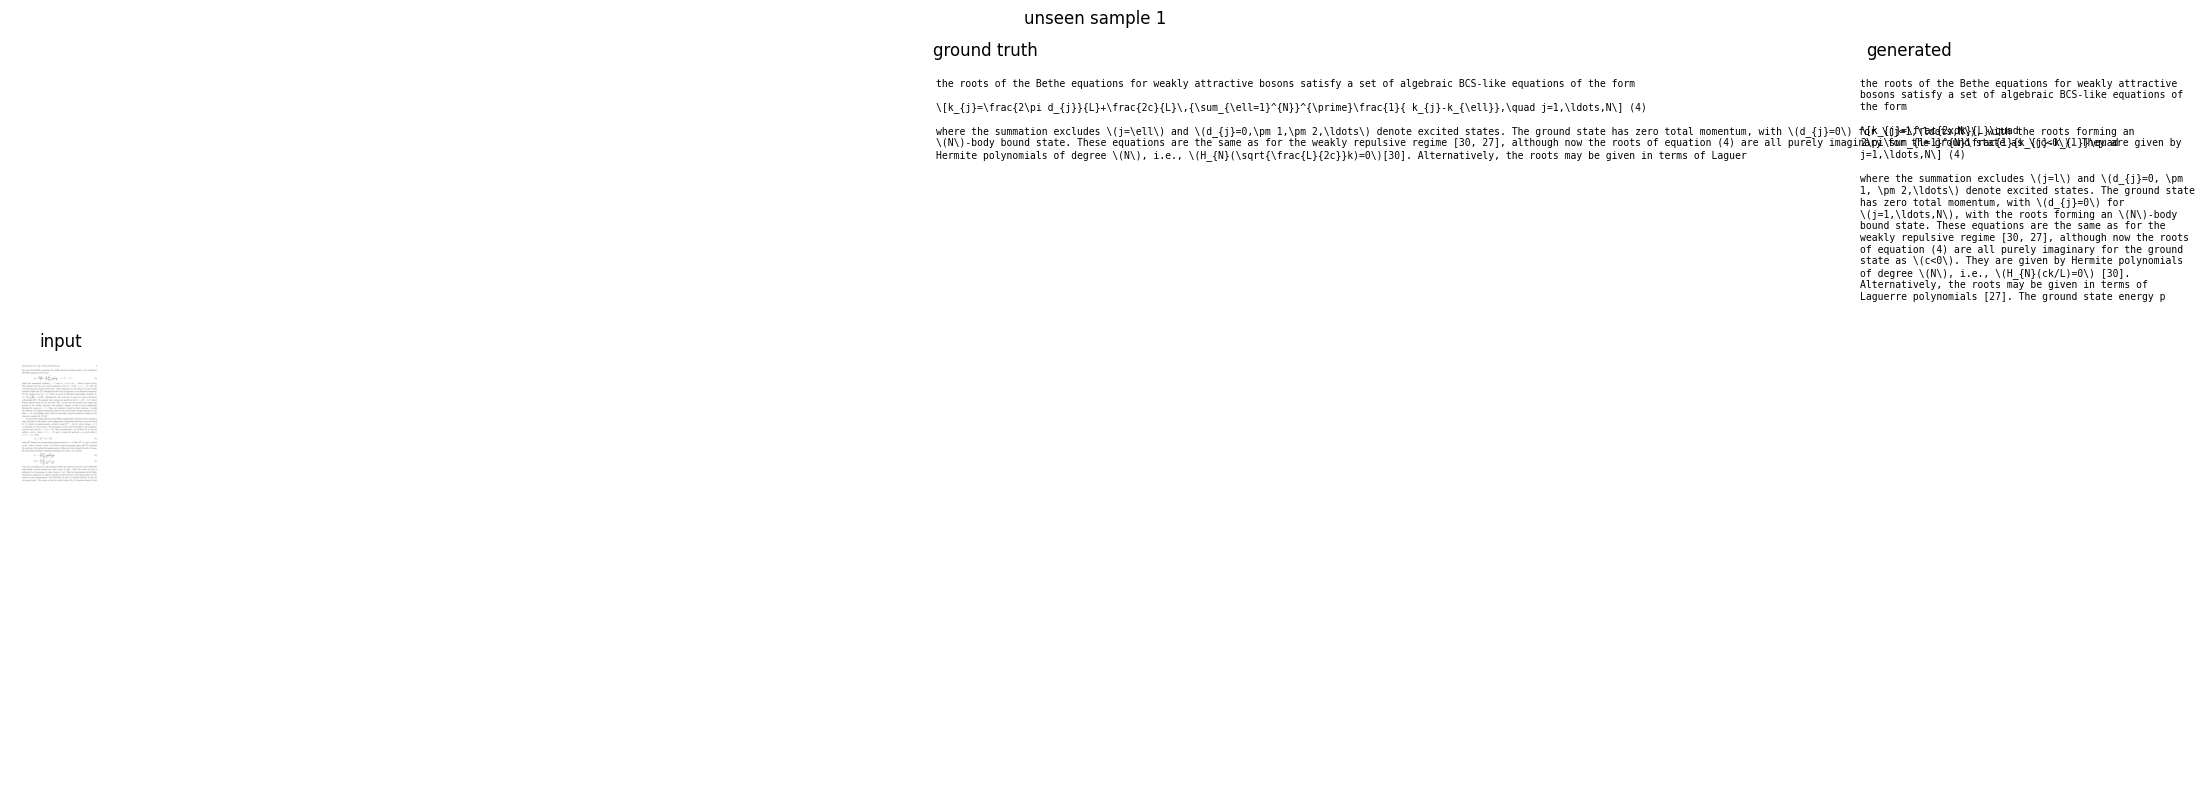

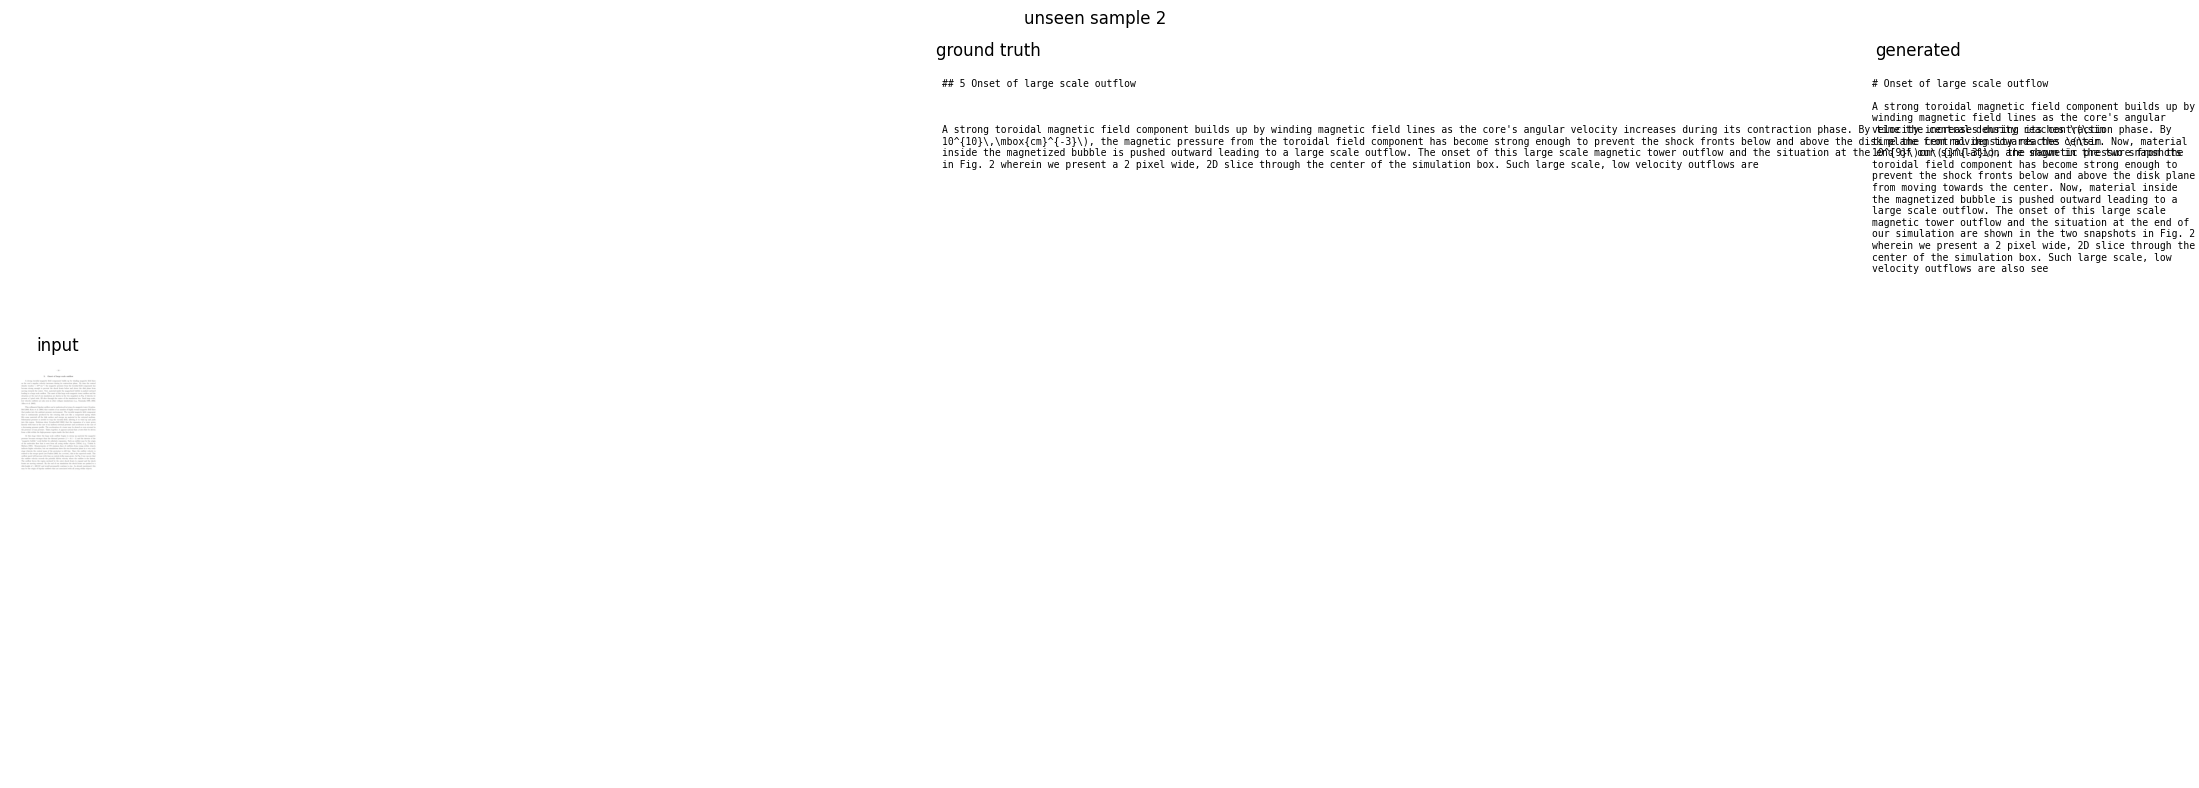

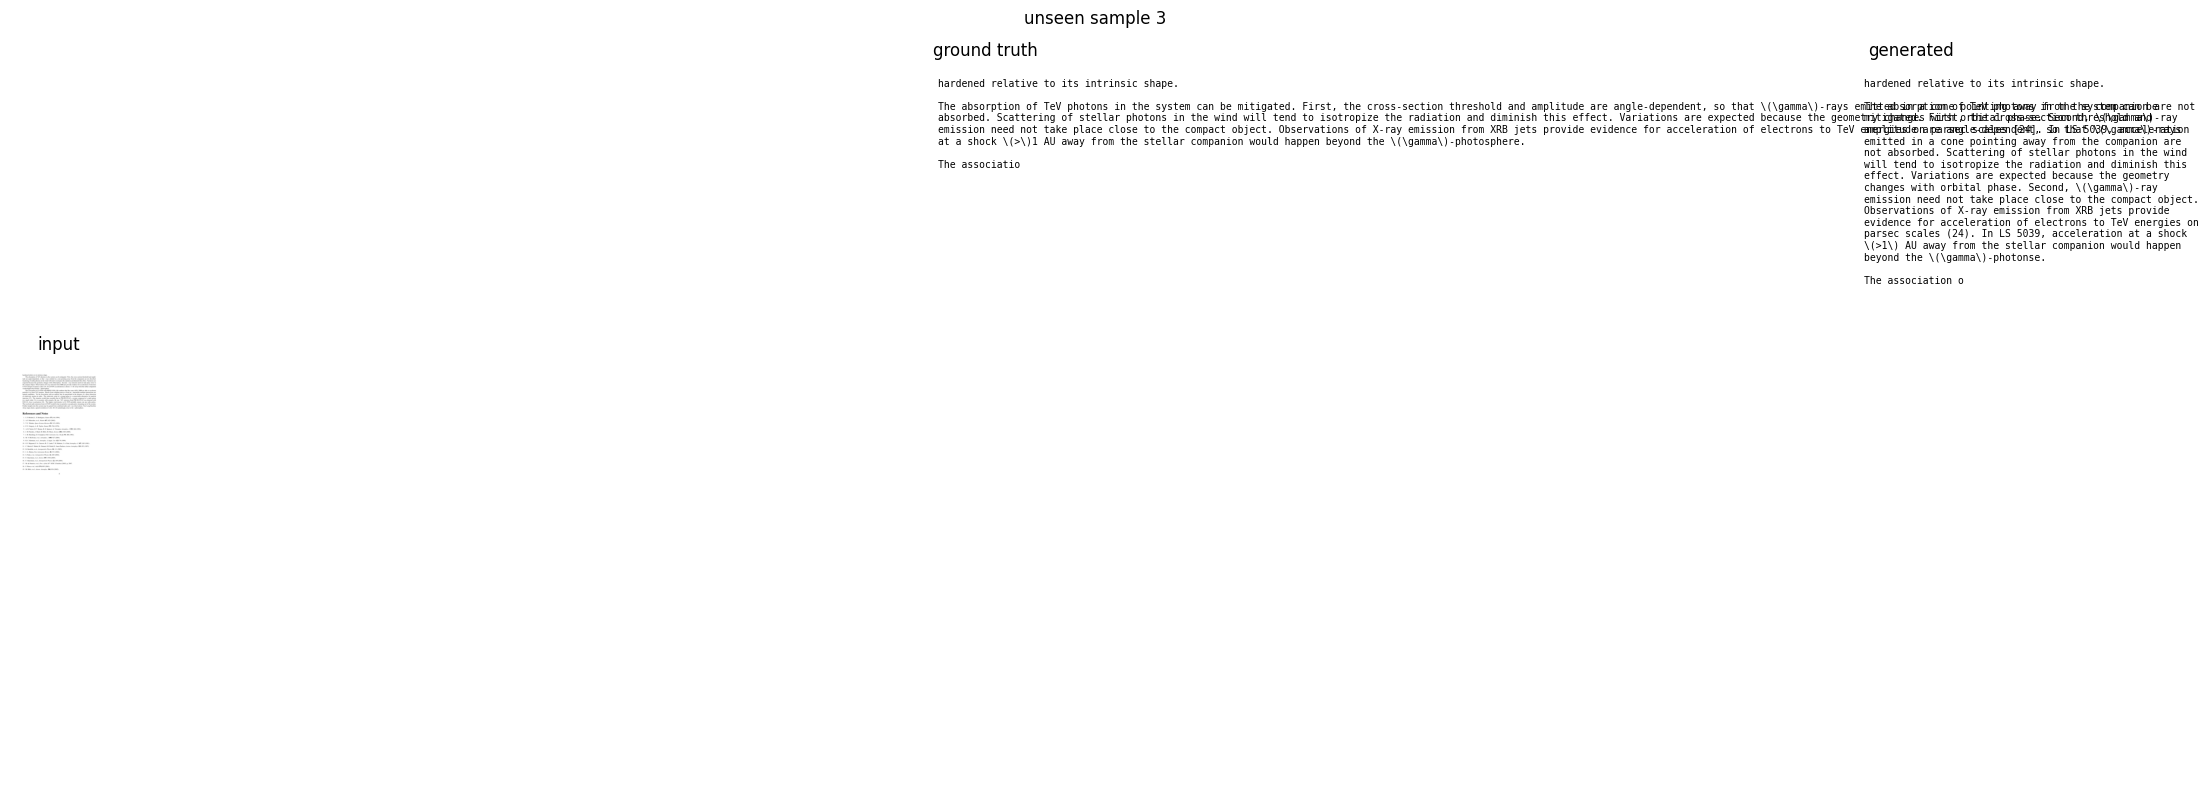

/usr/local/lib/python3.12/dist-packages/gradio/interface.py:415: UserWarning: The `allow_flagging` parameter in `Interface` is deprecated. Use `flagging_mode` instead.
  warnings.warn(


* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://34670f09b06ee25007.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [10]:
# side by side visualization: image | ground truth | generated
def show_result(r, title, save=None):
    fig, axes = plt.subplots(1, 3, figsize=(22, 8))
    axes[0].imshow(Image.open(r["image_path"]))
    axes[0].set_title("input")
    axes[0].axis("off")
    axes[1].text(0.02, 0.98, r["ground_truth"][:800], transform=axes[1].transAxes,
                 fontsize=7, va="top", family="monospace", wrap=True)
    axes[1].set_title("ground truth")
    axes[1].axis("off")
    axes[2].text(0.02, 0.98, r["generated"][:800], transform=axes[2].transAxes,
                 fontsize=7, va="top", family="monospace", wrap=True)
    axes[2].set_title("generated")
    axes[2].axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    if save:
        plt.savefig(save, dpi=150, bbox_inches="tight")
    plt.show()

for i, r in enumerate(train_results):
    show_result(r, f"training sample {i+1}", f"/kaggle/working/train_{i+1}.png")
for i, r in enumerate(val_results):
    show_result(r, f"unseen sample {i+1}", f"/kaggle/working/val_{i+1}.png")

# gradio app for easy testing
import gradio as gr

def app_fn(image):
    if image is None:
        return "upload an image first"
    tmp = "/kaggle/working/_upload.png"
    image.save(tmp)
    return generate_md(tmp)

demo = gr.Interface(
    fn=app_fn,
    inputs=gr.Image(type="pil", label="document image"),
    outputs=gr.Textbox(label="markdown output", lines=20, show_copy_button=True),
    title="document to markdown",
    description="qwen2-vl-2b fine-tuned with qlora on the nougat dataset",
    theme=gr.themes.Soft(),
    allow_flagging="never",
)
demo.launch(share=True, debug=False)

loading base model for zero-shot comparison


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

sample 1: zero-shot 2781 chars | fine-tuned 3147 chars
sample 2: zero-shot 3114 chars | fine-tuned 3140 chars


/tmp/ipykernel_23/1794372653.py:34: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


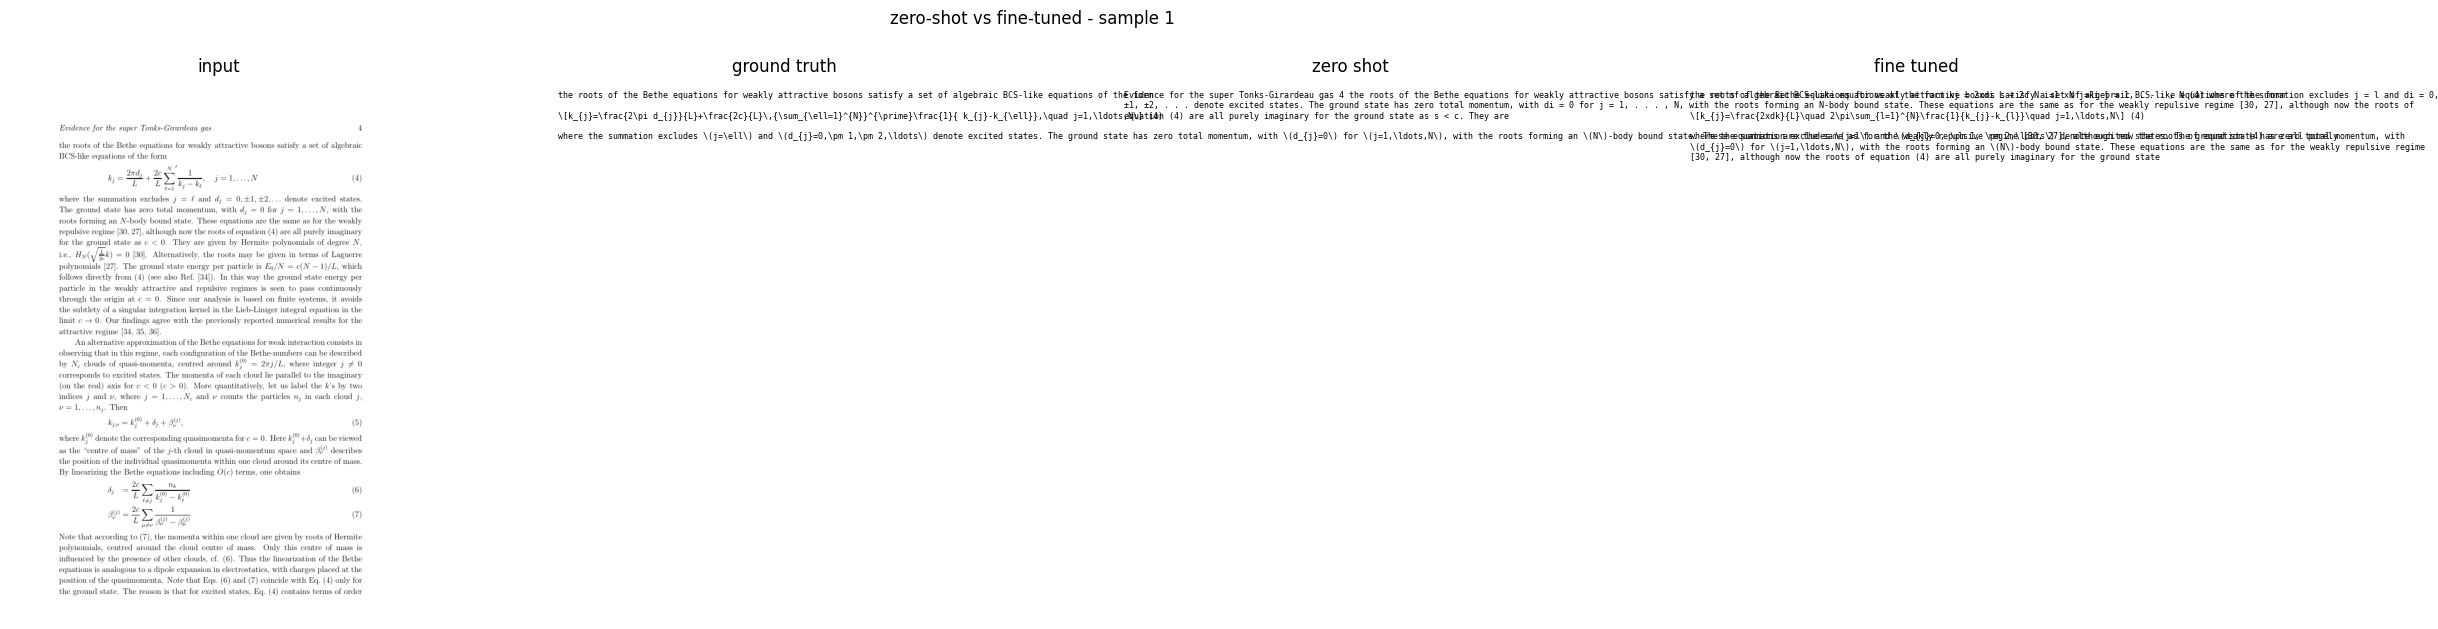

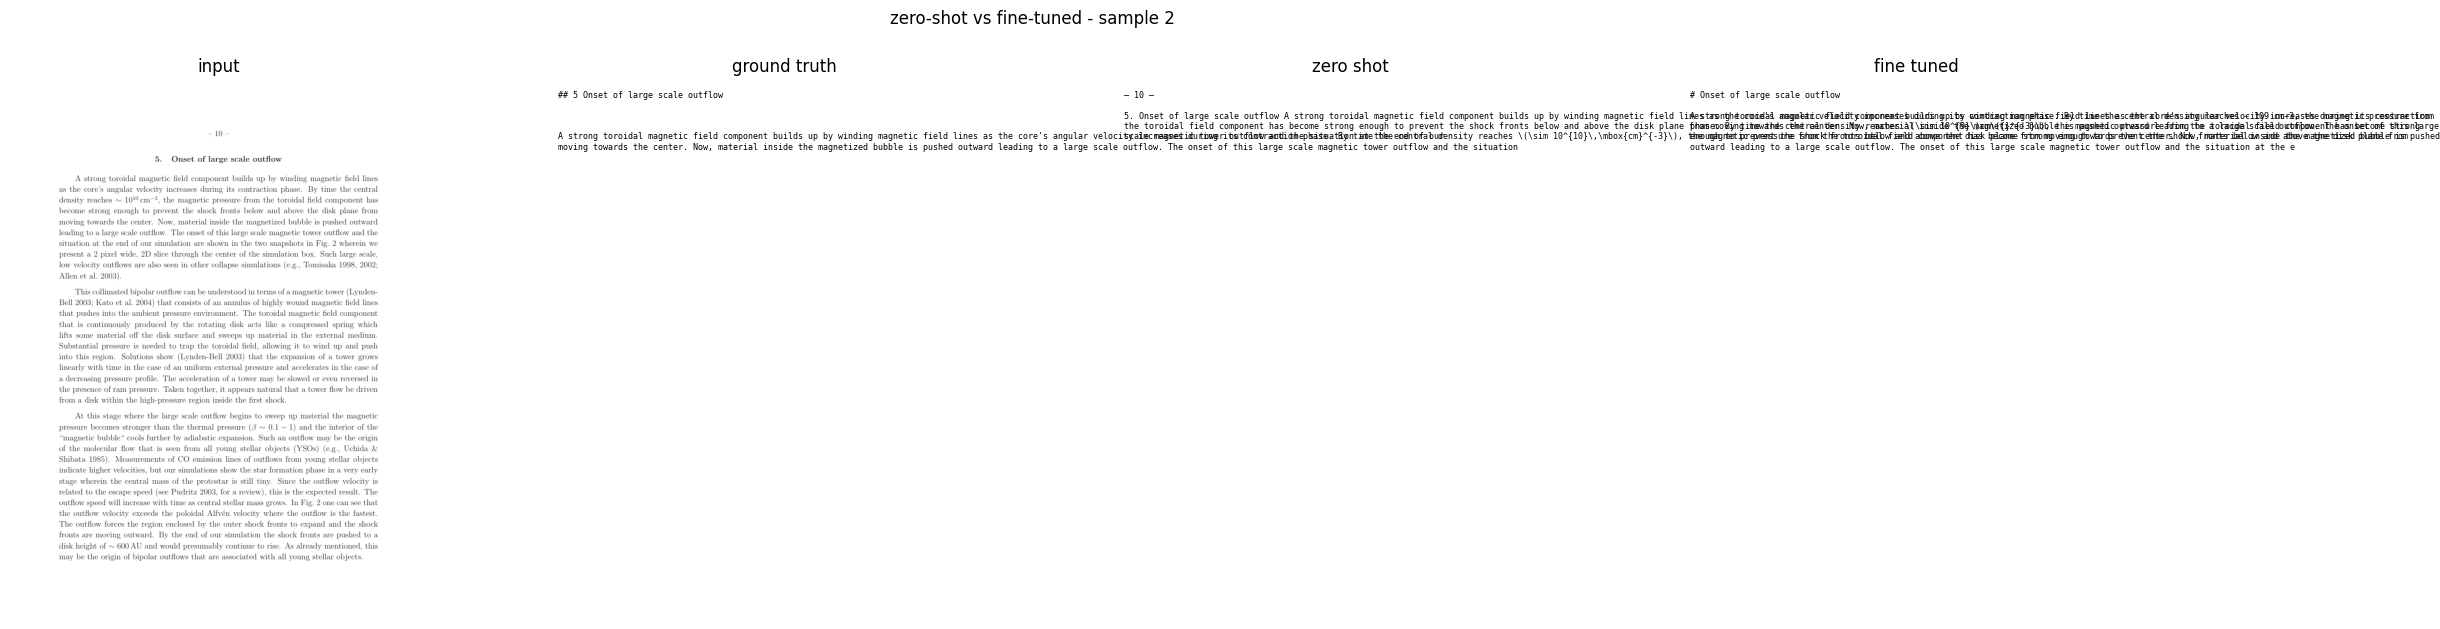

prompt 'minimal' -> 3189 chars
prompt 'detailed' -> 3147 chars
prompt 'structured' -> 3178 chars

run complete - all outputs in /kaggle/working/


In [11]:
# bonus: zero-shot baseline vs fine-tuned + prompt style comparison

print("loading base model for zero-shot comparison")
base_model = Qwen2VLForConditionalGeneration.from_pretrained(
    config["model_name"],
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.float16,
    trust_remote_code=True,
)

bonus_results = []
for i, idx in enumerate([0, len(val_data) // 2]):
    img, gt = get_sample_info(val_data[idx])
    zs = generate_md(img, mdl=base_model)
    ft = val_results[i]["generated"] if i < len(val_results) else generate_md(img)
    bonus_results.append({"image_path": img, "ground_truth": gt, "zero_shot": zs, "fine_tuned": ft})
    print(f"sample {i+1}: zero-shot {len(zs)} chars | fine-tuned {len(ft)} chars")

del base_model
torch.cuda.empty_cache()

for i, r in enumerate(bonus_results):
    fig, axes = plt.subplots(1, 4, figsize=(28, 7))
    axes[0].imshow(Image.open(r["image_path"]))
    axes[0].set_title("input")
    axes[0].axis("off")
    for j, key in enumerate(["ground_truth", "zero_shot", "fine_tuned"]):
        axes[j+1].text(0.02, 0.98, r[key][:600], transform=axes[j+1].transAxes,
                       fontsize=6, va="top", family="monospace", wrap=True)
        axes[j+1].set_title(key.replace("_", " "))
        axes[j+1].axis("off")
    plt.suptitle(f"zero-shot vs fine-tuned - sample {i+1}")
    plt.tight_layout()
    plt.savefig(f"/kaggle/working/bonus_{i+1}.png", dpi=150, bbox_inches="tight")
    plt.show()

# prompt style comparison
prompts = {
    "minimal": "Convert to markdown.",
    "detailed": config["user_prompt"],
    "structured": "Extract all text from this document image and format it as Markdown. Use # for titles, ## for sections. Preserve equations using LaTeX and maintain list formatting.",
}

img, _ = get_sample_info(val_data[0])
prompt_outputs = {}
original = config["user_prompt"]
for name, p in prompts.items():
    config["user_prompt"] = p
    prompt_outputs[name] = generate_md(img)
    print(f"prompt '{name}' -> {len(prompt_outputs[name])} chars")
config["user_prompt"] = original

# save run summary
summary = {
    "config": {k: v for k, v in config.items() if isinstance(v, (str, int, float, bool))},
    "train_samples": [{"image": os.path.basename(r["image_path"]),
                       "gt_len": len(r["ground_truth"]),
                       "gen_len": len(r["generated"])} for r in train_results],
    "val_samples": [{"image": os.path.basename(r["image_path"]),
                     "gt_len": len(r["ground_truth"]),
                     "gen_len": len(r["generated"])} for r in val_results],
    "prompt_comparison": {k: len(v) for k, v in prompt_outputs.items()},
}
with open("/kaggle/working/summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("\nrun complete - all outputs in /kaggle/working/")